In [1]:
# Complete Data Science Analysis for Student Performance Dataset
# Covering all 7 stages: Business Understanding, Data Understanding, Data Preparation, 
# EDA, Modeling, Evaluation, and Model Deployment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
import pickle
import joblib
from datetime import datetime


# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:

# ============================================================================
# STAGE 1: BUSINESS UNDERSTANDING
# ============================================================================
print("="*80)
print("STAGE 1: BUSINESS UNDERSTANDING")
print("="*80)
print("Goal: Predict student final grades (G3) and identify key factors affecting performance")
print("Dataset: Student Performance in Portuguese Language Course")
print()

STAGE 1: BUSINESS UNDERSTANDING
Goal: Predict student final grades (G3) and identify key factors affecting performance
Dataset: Student Performance in Portuguese Language Course



In [3]:

# ============================================================================
# STAGE 2: DATA UNDERSTANDING
# ============================================================================
print("="*80)
print("STAGE 2: DATA UNDERSTANDING")
print("="*80)

# Load the dataset
df = pd.read_csv("student-por.csv")

# 1. Shape of the dataset
print("\n1. Shape of the dataset:")
print(f"   Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. Column names and data types
print("\n2. Column names and data types:")
print(df.dtypes)

# 3. Summary statistics
print("\n3. Summary statistics for numeric variables:")
print(df.describe())

# 4. Missing values
print("\n4. Missing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   No missing values found!")
else:
    print("   Missing values detected!")
    print("\n   Columns with missing values:")
    missing_df = pd.DataFrame({
        'Column': missing[missing > 0].index,
        'Missing_Count': missing[missing > 0].values,
        'Percentage': (missing[missing > 0].values / len(df) * 100).round(2)
    })
    print(missing_df.to_string(index=False))
    
    print("\n   Handling missing values...")
    
    # Handle numeric columns with median
    numeric_missing = missing[missing > 0][df[missing[missing > 0].index].dtypes == 'float64'].index
    for col in numeric_missing:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"      • {col}: Filled with median value ({median_val:.2f})")
    
    # Handle categorical columns with mode
    categorical_missing = missing[missing > 0][df[missing[missing > 0].index].dtypes == 'object'].index
    for col in categorical_missing:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"      • {col}: Filled with mode value ({mode_val})")
    
    # Verify all missing values are handled
    if df.isnull().sum().sum() == 0:
        print("\n   All missing values handled successfully!")
    else:
        print("\n   Some missing values remain - consider alternative handling strategies")

# 5. First few rows of data
print("\n5. First few rows of data:")
print(df.head())


STAGE 2: DATA UNDERSTANDING

1. Shape of the dataset:
   Rows: 649, Columns: 33

2. Column names and data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

3. Summary statistics for numeric variables:
              age        Medu        Fedu  traveltime   studytime    failures  \
count  649.000000  649.000000  649.000000  649.000000

In [4]:

# ============================================================================
# STAGE 3: DATA PREPARATION
# ============================================================================
print("\n" + "="*80)
print("STAGE 3: DATA PREPARATION")
print("="*80)

# Store original data for visualizations
df_original = df.copy()

# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns
print(f"\n1. Encoding {len(categorical_cols)} categorical columns...")
print(f"   Categorical columns: {list(categorical_cols)}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"   Shape after encoding: {df_encoded.shape}")

# Check and remove duplicates
print("\n2. Checking for duplicate rows...")
duplicates = df_encoded.duplicated().sum()
print(f"   Duplicate rows found: {duplicates}")

if duplicates > 0:
    df_cleaned = df_encoded.drop_duplicates()
    print(f"   Shape after removing duplicates: {df_cleaned.shape}")
else:
    df_cleaned = df_encoded
    print("   No duplicates to remove")

df = df_cleaned




STAGE 3: DATA PREPARATION

1. Encoding 17 categorical columns...
   Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
   Shape after encoding: (649, 42)

2. Checking for duplicate rows...
   Duplicate rows found: 0
   No duplicates to remove



STAGE 3B: OUTLIER DETECTION

1. Box Plots for Outlier Detection:


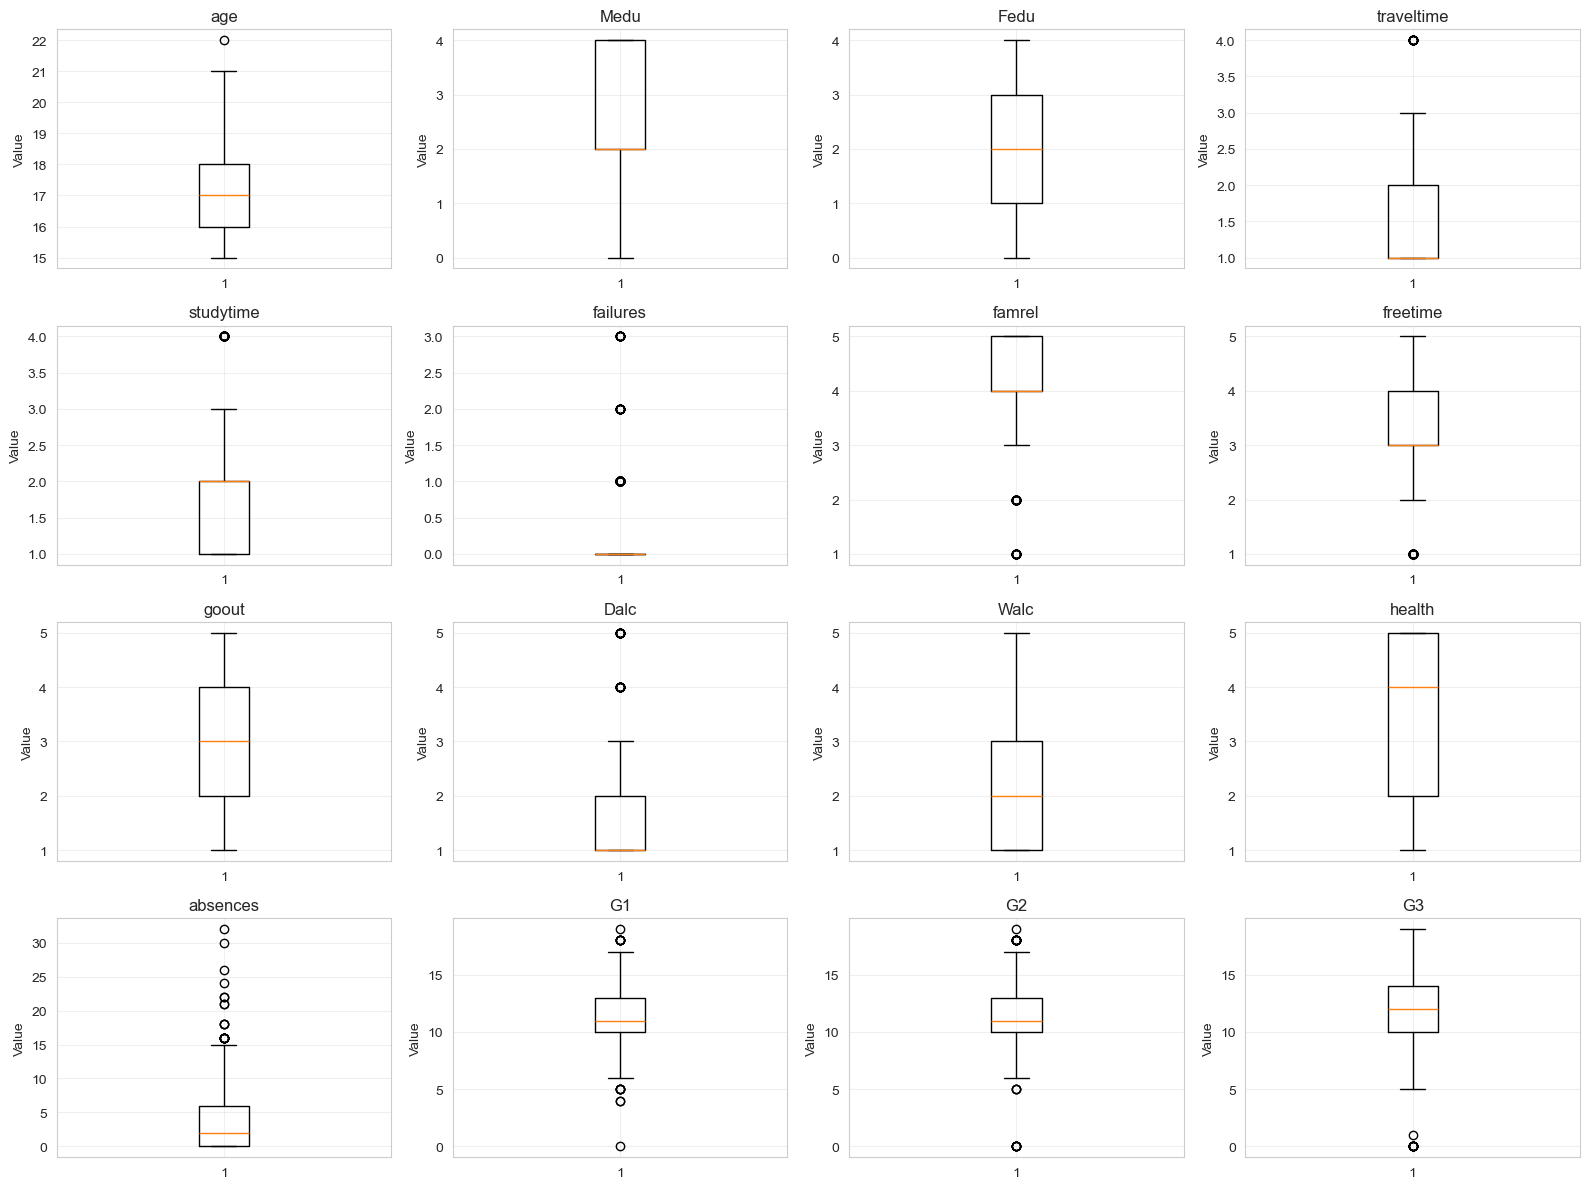


2. Outlier Statistics using IQR Method:
    Column   Q1   Q3  IQR  Lower_Bound  Upper_Bound  Outlier_Count  Outlier_Percentage
       age 16.0 18.0  2.0         13.0         21.0              1            0.154083
      Medu  2.0  4.0  2.0         -1.0          7.0              0            0.000000
      Fedu  1.0  3.0  2.0         -2.0          6.0              0            0.000000
traveltime  1.0  2.0  1.0         -0.5          3.5             16            2.465331
 studytime  1.0  2.0  1.0         -0.5          3.5             35            5.392912
  failures  0.0  0.0  0.0          0.0          0.0            100           15.408320
    famrel  4.0  5.0  1.0          2.5          6.5             51            7.858243
  freetime  3.0  4.0  1.0          1.5          5.5             45            6.933744
     goout  2.0  4.0  2.0         -1.0          7.0              0            0.000000
      Dalc  1.0  2.0  1.0         -0.5          3.5             34            5.238829
  

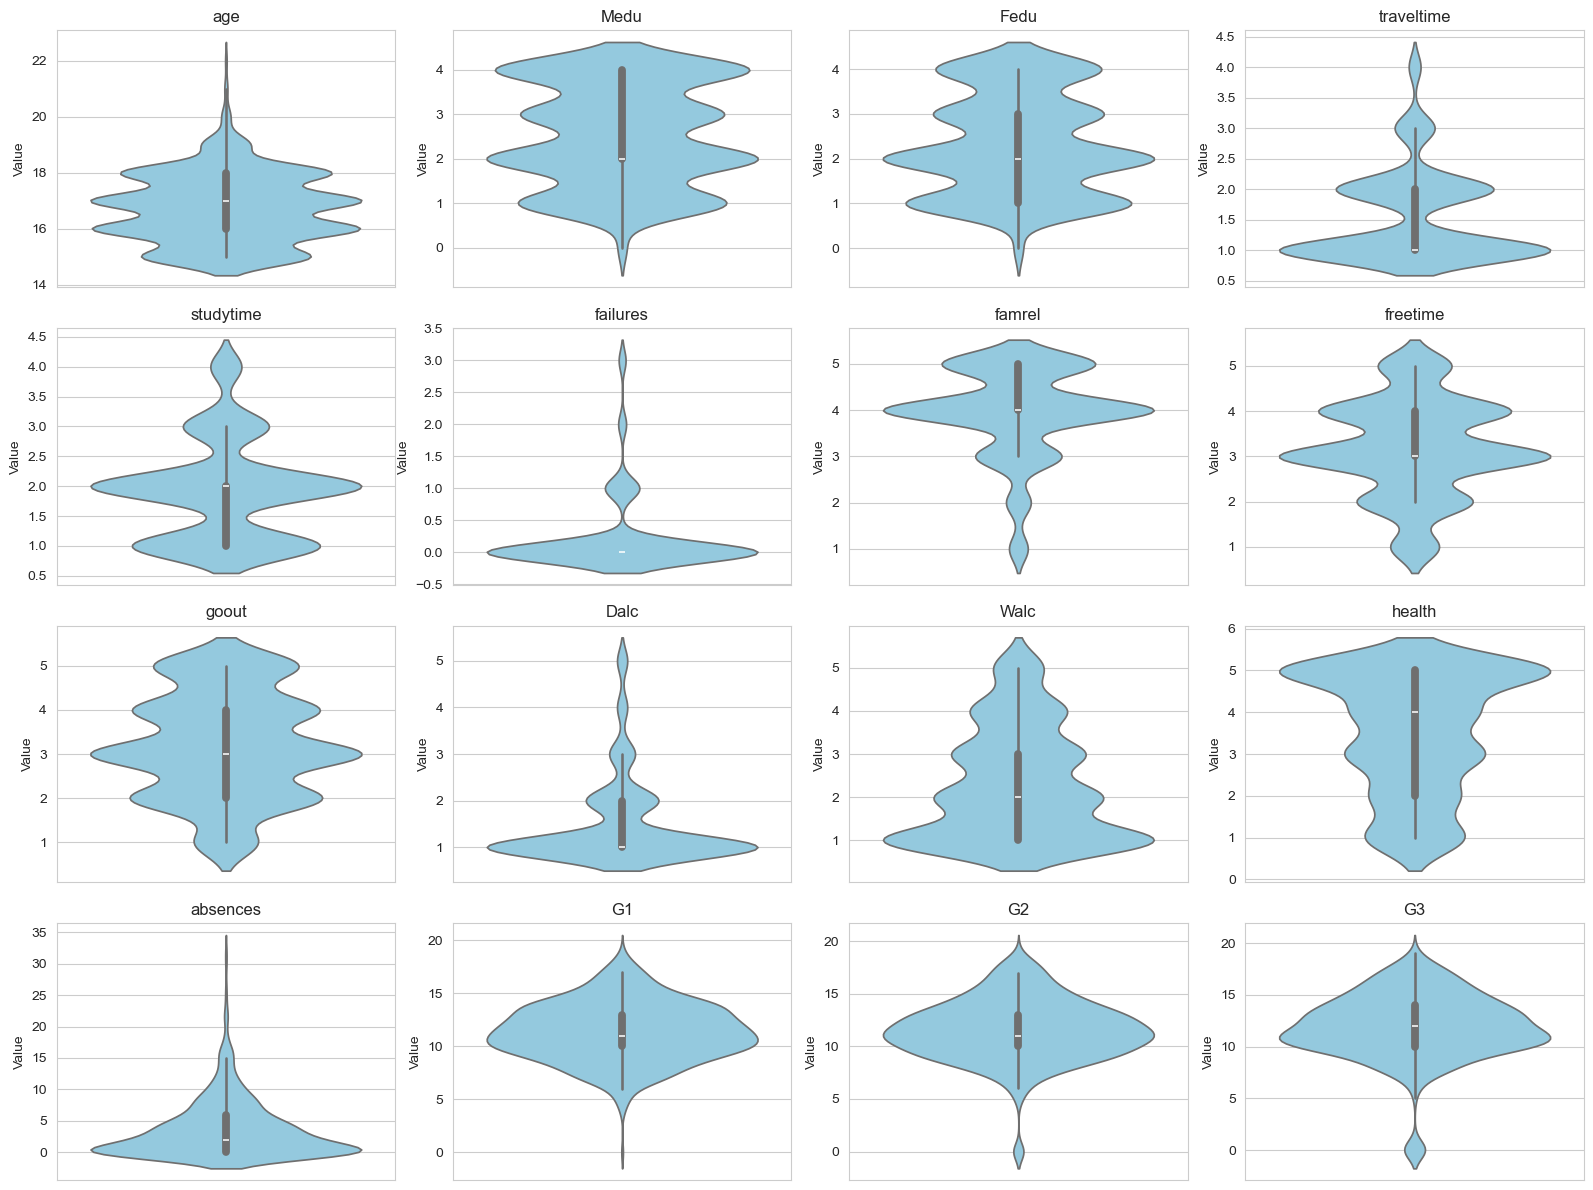


4. Outlier Handling Decision:
   Based on domain knowledge, keeping outliers as they represent valid student data
   (e.g., high absences, multiple failures are legitimate observations)


In [5]:
# ============================================================================
# STAGE 3B: OUTLIER DETECTION AND HANDLING
# ============================================================================
print("\n" + "="*80)
print("STAGE 3B: OUTLIER DETECTION")
print("="*80)

# Select numeric columns for outlier detection (excluding encoded binary columns)
numeric_cols_for_outliers = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 
                               'failures', 'famrel', 'freetime', 'goout', 'Dalc', 
                               'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

print("\n1. Box Plots for Outlier Detection:")
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols_for_outliers):
    axes[idx].boxplot(df_original[col], vert=True)
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(len(numeric_cols_for_outliers), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

plt.savefig('static/analysis/outlier_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# IQR method for outlier detection
print("\n2. Outlier Statistics using IQR Method:")
outlier_summary = []

for col in numeric_cols_for_outliers:
    Q1 = df_original[col].quantile(0.25)
    Q3 = df_original[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_original[(df_original[col] < lower_bound) | (df_original[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df_original)) * 100
    
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

print("\n3. Visualization: Outliers Distribution")
# Violin plots for better outlier visualization
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols_for_outliers):
    sns.violinplot(y=df_original[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel('Value')

for idx in range(len(numeric_cols_for_outliers), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('static/analysis/outlier_violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Decision on outliers
print("\n4. Outlier Handling Decision:")
print("   Based on domain knowledge, keeping outliers as they represent valid student data")
print("   (e.g., high absences, multiple failures are legitimate observations)")


STAGE 4: EXPLORATORY DATA ANALYSIS

1. Distribution Analysis:


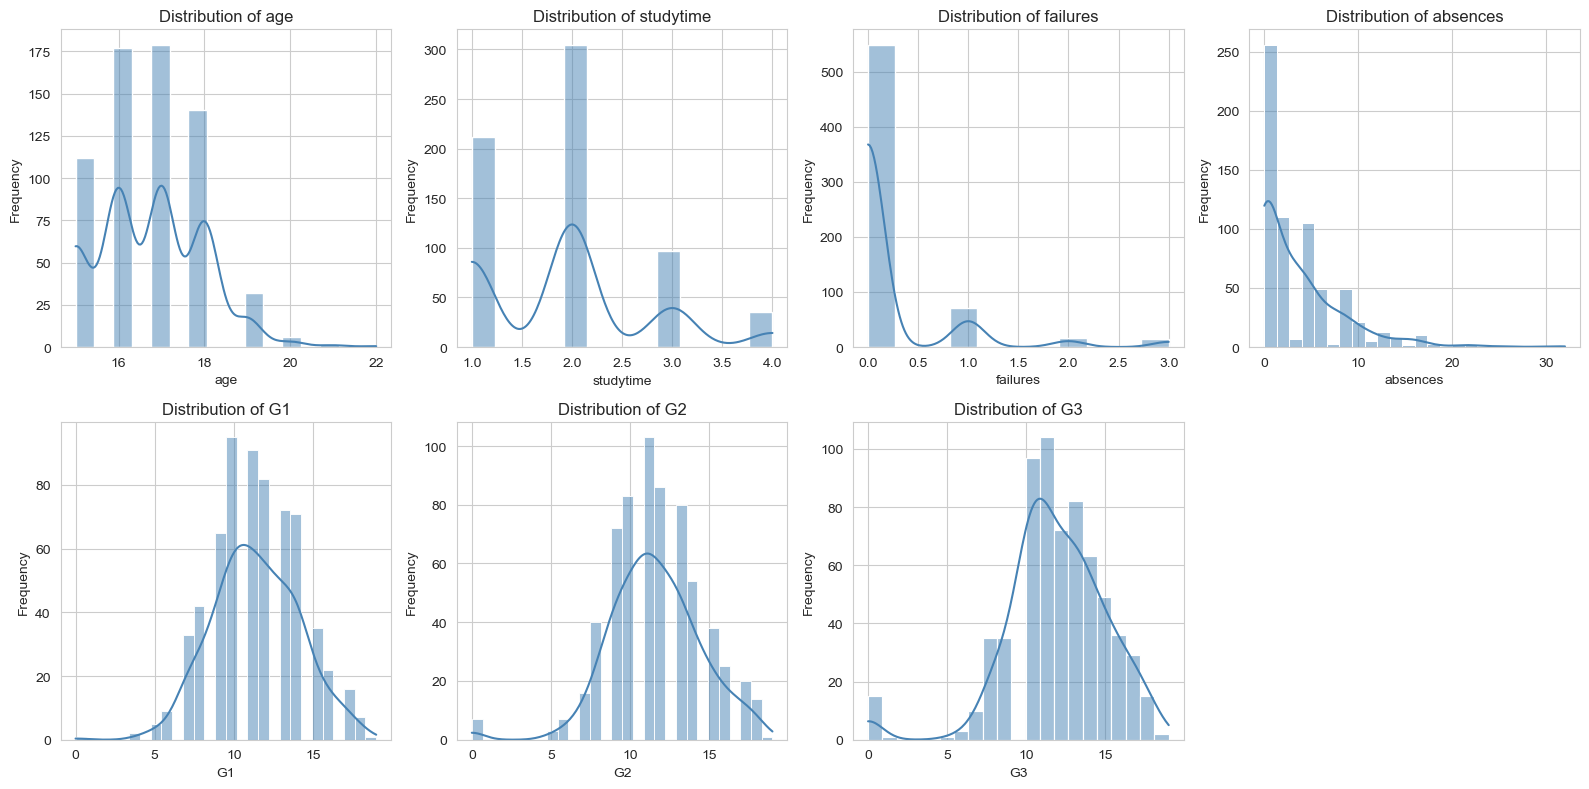


Skewness of key numeric variables:
age          0.416795
studytime    0.699619
failures     3.092699
absences     2.020694
G1          -0.002774
G2          -0.360283
G3          -0.912909
dtype: float64

2. Categorical Variable Analysis:


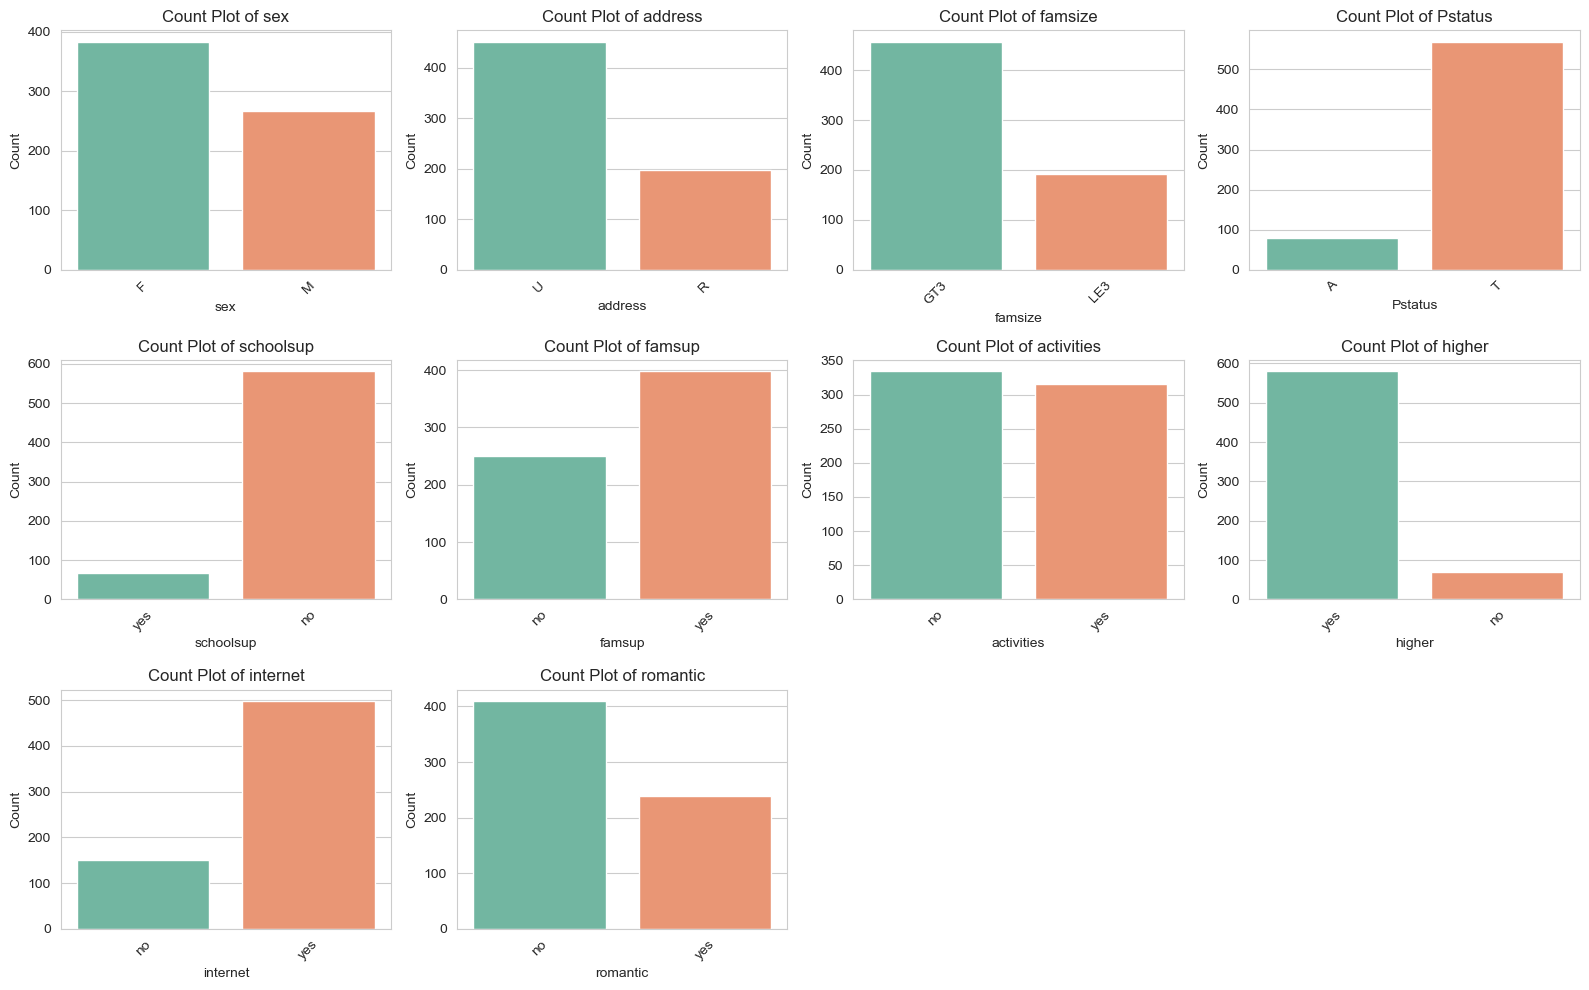


3. Correlation Analysis:


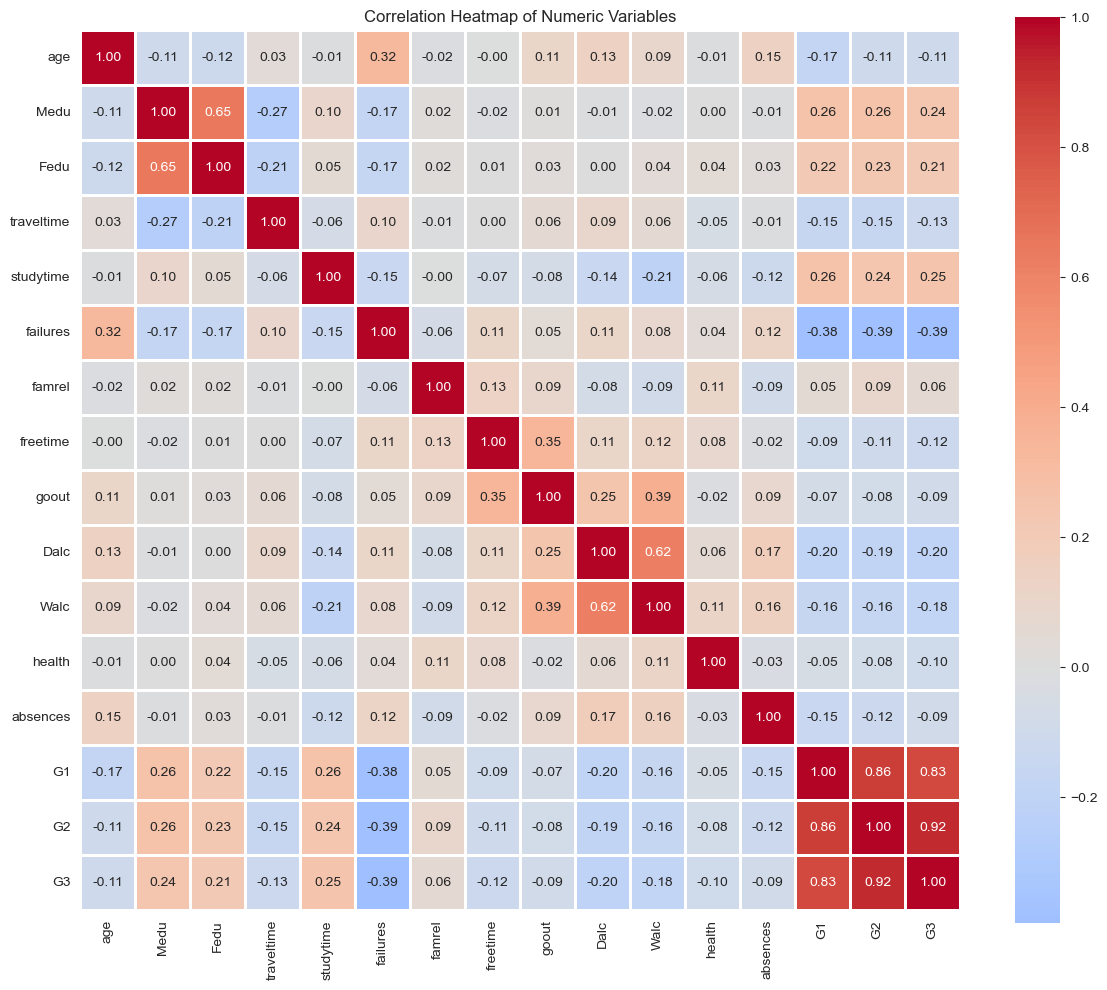


4. Key Correlations with Final Grade (G3):
G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


In [6]:
# ============================================================================
# STAGE 4: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================
print("\n" + "="*80)
print("STAGE 4: EXPLORATORY DATA ANALYSIS")
print("="*80)

# Distribution plots for key numeric variables
print("\n1. Distribution Analysis:")
key_numeric = ['age', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(key_numeric):
    sns.histplot(df_original[col], kde=True, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

fig.delaxes(axes[7])
plt.tight_layout()
plt.savefig('static/analysis/distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Skewness calculation for numeric variables
print("\nSkewness of key numeric variables:")
skew_values = df_original[key_numeric].skew()
print(skew_values)

# Count plots for key categorical variables
print("\n2. Categorical Variable Analysis:")
key_categorical = ['sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 
                   'famsup', 'activities', 'higher', 'internet', 'romantic']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(key_categorical):
    sns.countplot(data=df_original, x=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'Count Plot of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

for idx in range(len(key_categorical), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('static/analysis/categorical_counts.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap
print("\n3. Correlation Analysis:")
plt.figure(figsize=(12, 10))
correlation_matrix = df_original[numeric_cols_for_outliers].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.savefig('static/analysis/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Key insights
print("\n4. Key Correlations with Final Grade (G3):")
g3_corr = correlation_matrix['G3'].sort_values(ascending=False)
print(g3_corr)


In [7]:
# ============================================================================
# STAGE 4B: HYPOTHESIS TESTING
# ============================================================================
print("\n" + "="*80)
print("STAGE 4B: HYPOTHESIS TESTING")
print("="*80)

# Test 1: Gender vs Final Grade
print("\n1. T-Test: Gender vs Final Grade (G3)")
print("   H0: No difference in grades between male and female students")
print("   H1: Significant difference exists")

male_grades = df[df['sex_M'] == 1]['G3']
female_grades = df[df['sex_M'] == 0]['G3']
ttest_gender = ttest_ind(male_grades, female_grades)

print(f"   Male mean: {male_grades.mean():.2f}, Female mean: {female_grades.mean():.2f}")
print(f"   Test Statistic: {ttest_gender.statistic:.4f}")
print(f"   P-value: {ttest_gender.pvalue:.4f}")
print(f"   Conclusion: {'Reject H0' if ttest_gender.pvalue < 0.05 else 'Fail to reject H0'}")

# Test 2: Internet Access vs Final Grade
print("\n2. T-Test: Internet Access vs Final Grade (G3)")
print("   H0: No difference in grades between students with/without internet")
print("   H1: Significant difference exists")

internet_yes = df[df['internet_yes'] == 1]['G3']
internet_no = df[df['internet_yes'] == 0]['G3']
ttest_internet = ttest_ind(internet_yes, internet_no)

print(f"   With Internet mean: {internet_yes.mean():.2f}, Without mean: {internet_no.mean():.2f}")
print(f"   Test Statistic: {ttest_internet.statistic:.4f}")
print(f"   P-value: {ttest_internet.pvalue:.4f}")
print(f"   Conclusion: {'Reject H0' if ttest_internet.pvalue < 0.05 else 'Fail to reject H0'}")

# Test 3: Study Time vs Final Grade
print("\n3. T-Test: Study Time (Low vs High) vs Final Grade (G3)")
print("   H0: No difference between low (<=2) and high (>2) study time")
print("   H1: Significant difference exists")

low_study = df[df['studytime'] <= 2]['G3']
high_study = df[df['studytime'] > 2]['G3']
ttest_study = ttest_ind(low_study, high_study)

print(f"   Low study time mean: {low_study.mean():.2f}, High study time mean: {high_study.mean():.2f}")
print(f"   Test Statistic: {ttest_study.statistic:.4f}")
print(f"   P-value: {ttest_study.pvalue:.4f}")
print(f"   Conclusion: {'Reject H0' if ttest_study.pvalue < 0.05 else 'Fail to reject H0'}")

# Test 4: Absences vs Final Grade (Correlation)
print("\n4. Pearson Correlation: Absences vs Final Grade (G3)")
print("   H0: No linear relationship between absences and grades")
print("   H1: Significant linear relationship exists")

pearson_abs, pval_abs = pearsonr(df['absences'], df['G3'])
print(f"   Pearson R: {pearson_abs:.4f}")
print(f"   P-value: {pval_abs:.4f}")
print(f"   Conclusion: {'Reject H0' if pval_abs < 0.05 else 'Fail to reject H0'}")

# Test 5: Father's Education vs Final Grade (Correlation)
print("\n5. Pearson Correlation: Father's Education vs Final Grade (G3)")
print("   H0: No linear relationship between father's education and grades")
print("   H1: Significant linear relationship exists")

pearson_fedu, pval_fedu = pearsonr(df['Fedu'], df['G3'])
print(f"   Pearson R: {pearson_fedu:.4f}")
print(f"   P-value: {pval_fedu:.4f}")
print(f"   Conclusion: {'Reject H0' if pval_fedu < 0.05 else 'Fail to reject H0'}")



STAGE 4B: HYPOTHESIS TESTING

1. T-Test: Gender vs Final Grade (G3)
   H0: No difference in grades between male and female students
   H1: Significant difference exists
   Male mean: 11.41, Female mean: 12.25
   Test Statistic: -3.3109
   P-value: 0.0010
   Conclusion: Reject H0

2. T-Test: Internet Access vs Final Grade (G3)
   H0: No difference in grades between students with/without internet
   H1: Significant difference exists
   With Internet mean: 12.17, Without mean: 11.03
   Test Statistic: 3.8597
   P-value: 0.0001
   Conclusion: Reject H0

3. T-Test: Study Time (Low vs High) vs Final Grade (G3)
   H0: No difference between low (<=2) and high (>2) study time
   H1: Significant difference exists
   Low study time mean: 11.58, High study time mean: 13.18
   Test Statistic: -5.1839
   P-value: 0.0000
   Conclusion: Reject H0

4. Pearson Correlation: Absences vs Final Grade (G3)
   H0: No linear relationship between absences and grades
   H1: Significant linear relationship exist


STAGE 4C: PRINCIPAL COMPONENT ANALYSIS (PCA)

1. Standardizing features for PCA...

2. Applying PCA...

3. Explained Variance by Components:
   PC1: 0.2002 (Cumulative: 0.2002)
   PC2: 0.1290 (Cumulative: 0.3292)
   PC3: 0.0896 (Cumulative: 0.4188)
   PC4: 0.0846 (Cumulative: 0.5034)
   PC5: 0.0751 (Cumulative: 0.5785)
   PC6: 0.0664 (Cumulative: 0.6449)
   PC7: 0.0607 (Cumulative: 0.7056)
   PC8: 0.0573 (Cumulative: 0.7629)
   PC9: 0.0531 (Cumulative: 0.8160)
   PC10: 0.0514 (Cumulative: 0.8674)

4. Scree Plot:


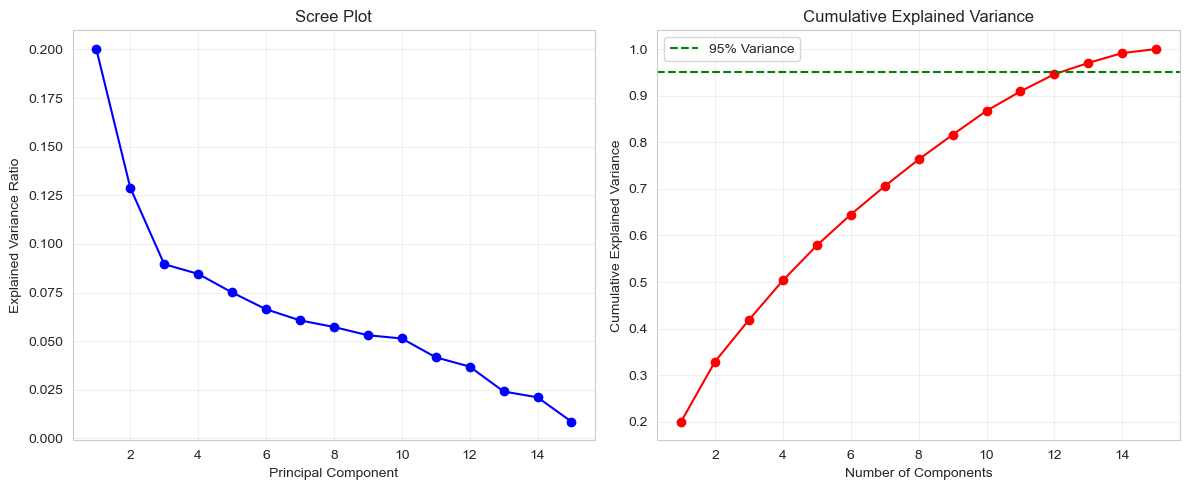


5. Number of components explaining 95% variance: 13

6. Original feature space: 15 dimensions
   Reduced feature space: 13 dimensions
   Dimensionality reduction: 13.3%

7. Feature Loadings for Top 3 Principal Components:
                 PC1       PC2       PC3
age        -0.200499 -0.003577 -0.137697
Medu        0.276077  0.394384 -0.309817
Fedu        0.242098  0.418114 -0.302157
traveltime -0.181554 -0.162545  0.238100
studytime   0.232106 -0.087395  0.059234
failures   -0.324578 -0.092752 -0.176521
famrel      0.060336  0.032875  0.431204
freetime   -0.130181  0.225142  0.434317
goout      -0.173364  0.383290  0.365378
Dalc       -0.270568  0.397564 -0.007906
Walc       -0.265537  0.457966  0.057083
health     -0.052864  0.110380  0.104839
absences   -0.159093  0.150552 -0.341282
G1          0.454834  0.112987  0.184248
G2          0.451050  0.113497  0.172022


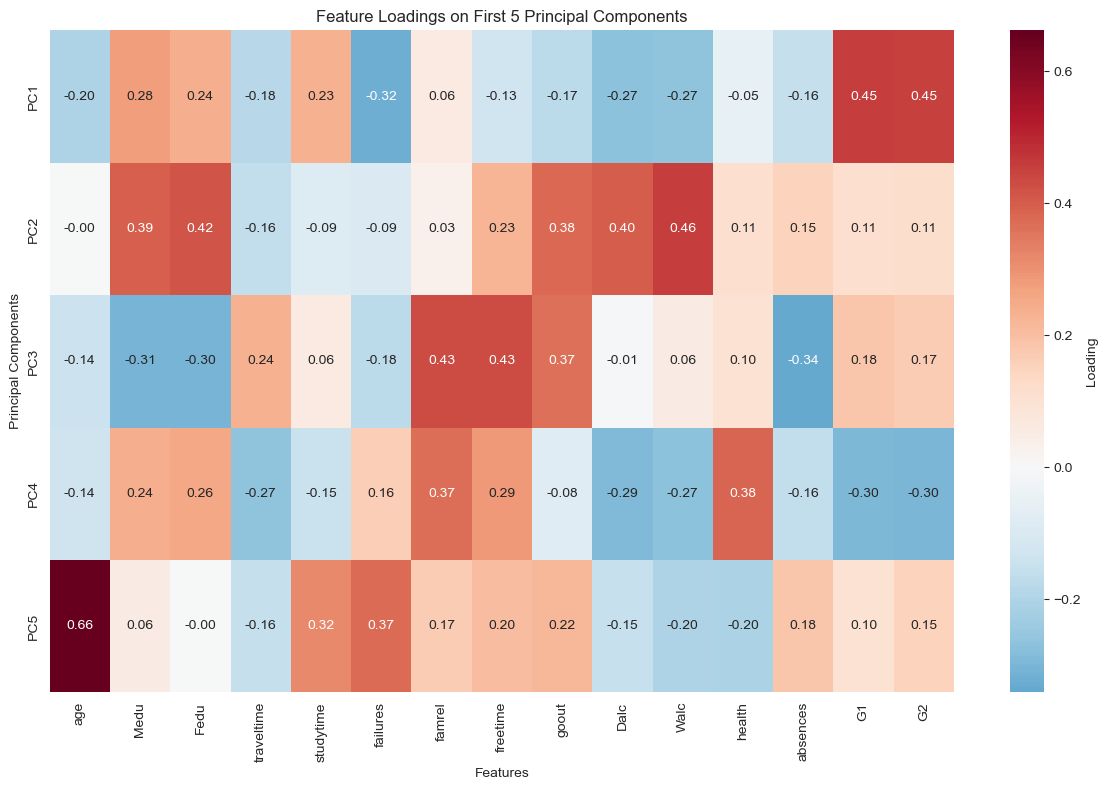


8. PCA Biplot (PC1 vs PC2):


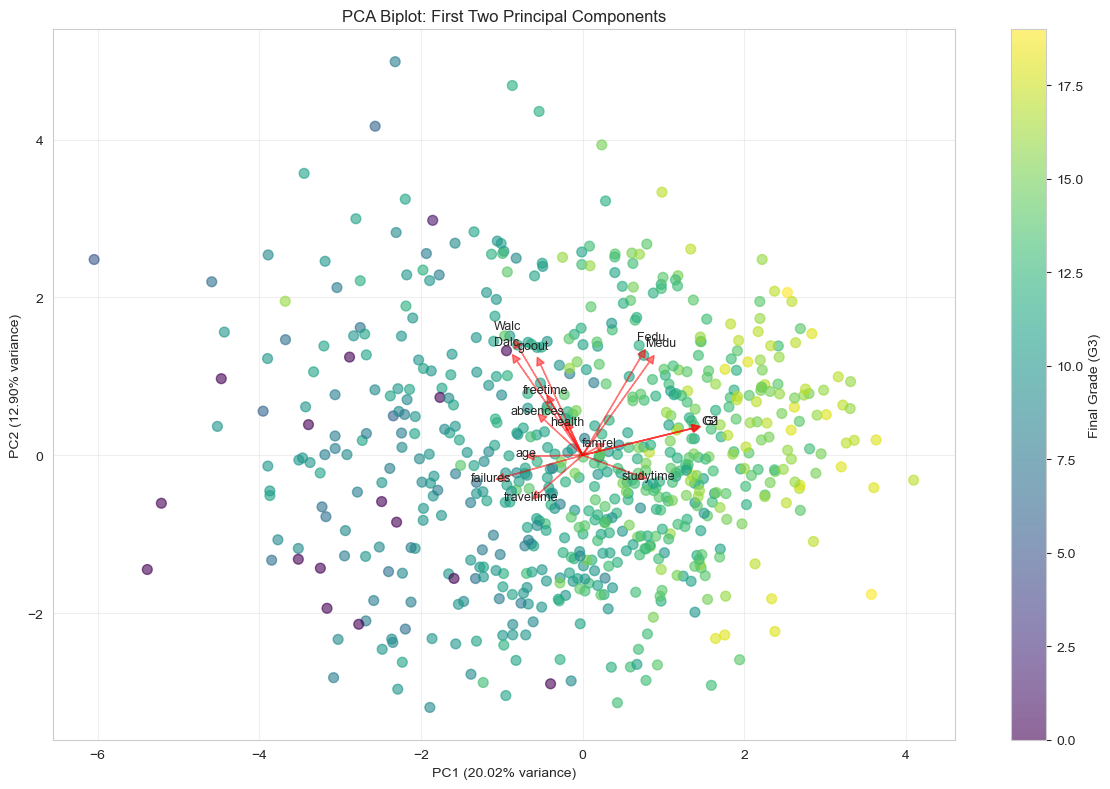

In [8]:
# ============================================================================
# STAGE 4C: PRINCIPAL COMPONENT ANALYSIS (PCA)
# ============================================================================
print("\n" + "="*80)
print("STAGE 4C: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("="*80)

# Prepare data for PCA (use only numeric features, exclude target G3)
numeric_features = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 
                    'failures', 'famrel', 'freetime', 'goout', 'Dalc', 
                    'Walc', 'health', 'absences', 'G1', 'G2']

X_pca = df[numeric_features]
y_pca = df['G3']

# Standardize the features
print("\n1. Standardizing features for PCA...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# Apply PCA
print("\n2. Applying PCA...")
pca = PCA()
X_pca_transformed = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\n3. Explained Variance by Components:")
for i, (exp_var, cum_var) in enumerate(zip(explained_variance[:10], cumulative_variance[:10])):
    print(f"   PC{i+1}: {exp_var:.4f} (Cumulative: {cum_var:.4f})")

# Scree plot
print("\n4. Scree Plot:")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('static/analysis/pca_scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Determine optimal number of components
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\n5. Number of components explaining 95% variance: {n_components_95}")

# PCA with optimal components
pca_optimal = PCA(n_components=n_components_95)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

print(f"\n6. Original feature space: {X_pca.shape[1]} dimensions")
print(f"   Reduced feature space: {X_pca_optimal.shape[1]} dimensions")
print(f"   Dimensionality reduction: {(1 - n_components_95/X_pca.shape[1])*100:.1f}%")

# Feature importance in principal components
print("\n7. Feature Loadings for Top 3 Principal Components:")
loadings = pd.DataFrame(
    pca_optimal.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=numeric_features
)
print(loadings.iloc[:, :3].to_string())

# Visualize loadings
plt.figure(figsize=(12, 8))
sns.heatmap(loadings.iloc[:, :5].T, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, cbar_kws={'label': 'Loading'})
plt.title('Feature Loadings on First 5 Principal Components')
plt.xlabel('Features')
plt.ylabel('Principal Components')
plt.tight_layout()
plt.savefig('static/analysis/pca_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

# Biplot for first two components
print("\n8. PCA Biplot (PC1 vs PC2):")
fig, ax = plt.subplots(figsize=(12, 8))

# Plot data points
scatter = ax.scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], 
                    c=y_pca, cmap='viridis', alpha=0.6, s=50)
ax.set_xlabel(f'PC1 ({explained_variance[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({explained_variance[1]:.2%} variance)')
ax.set_title('PCA Biplot: First Two Principal Components')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Final Grade (G3)')

# Plot feature vectors
for i, feature in enumerate(numeric_features):
    ax.arrow(0, 0, pca.components_[0, i]*3, pca.components_[1, i]*3,
            head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.5)
    ax.text(pca.components_[0, i]*3.5, pca.components_[1, i]*3.5, 
           feature, fontsize=9, ha='center')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('static/analysis/pca_biplot.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
# ============================================================================
# STAGE 5: MODELING
# ============================================================================
print("\n" + "="*80)
print("STAGE 5: MODELING")
print("="*80)

# Define features and target
features = ['studytime', 'absences', 'G1', 'G2', 'Medu', 'Fedu', 'failures']
target = 'G3'

print(f"\nFeatures selected: {features}")
print(f"Target variable: {target}")

# Split data
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Train Linear Regression model
print("\nTraining Linear Regression model...")
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

# Display coefficients
print("\nModel Coefficients:")
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")



STAGE 5: MODELING

Features selected: ['studytime', 'absences', 'G1', 'G2', 'Medu', 'Fedu', 'failures']
Target variable: G3

Training set: 519 samples
Test set: 130 samples

Training Linear Regression model...
Model trained successfully!

Model Coefficients:
  Feature  Coefficient
       G2     0.877035
       G1     0.183758
 failures    -0.161202
studytime     0.116756
     Medu    -0.078454
 absences     0.025858
     Fedu     0.015295

Intercept: -0.4434



STAGE 6: MODEL EVALUATION

Model Performance Metrics:
  R-squared (R²): 0.8609
  Mean Absolute Error (MAE): 0.7410
  Root Mean Squared Error (RMSE): 1.1645

Interpretation:
  - The model explains 86.09% of variance in final grades
  - Average prediction error: ±0.74 points
  - Typical prediction error: ±1.16 points

Generating visualization: Actual vs Predicted Grades


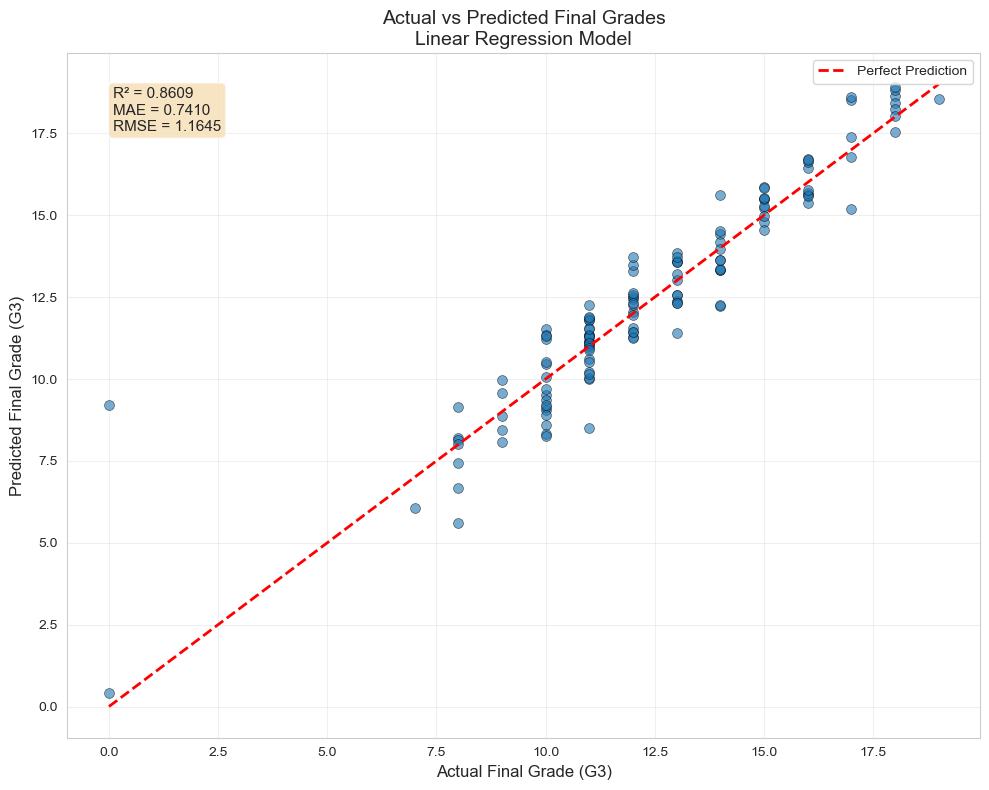


Generating Residual Analysis


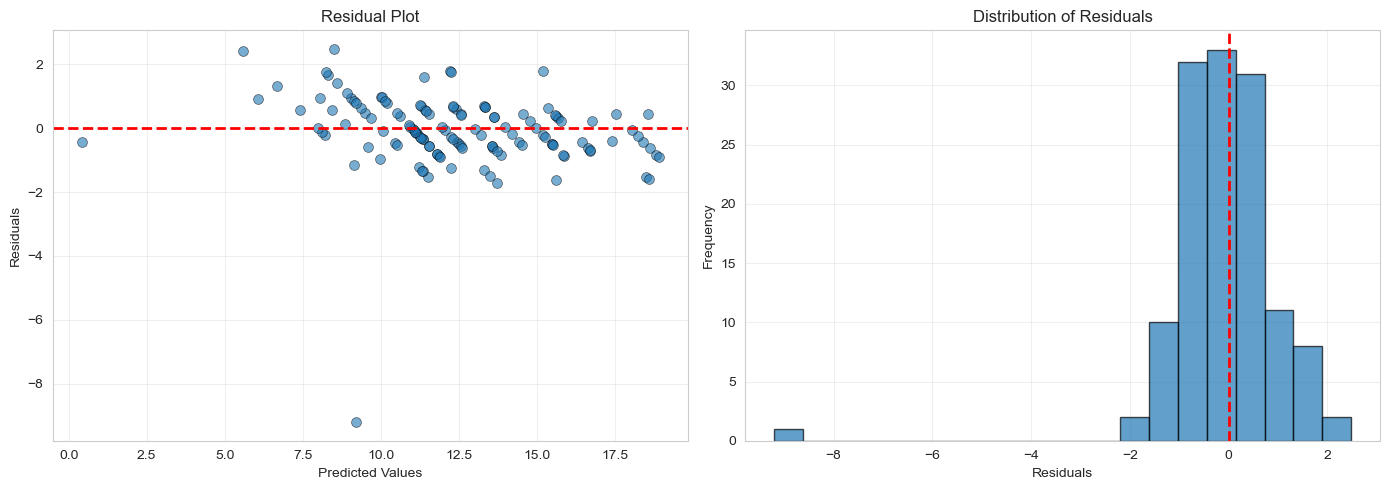

In [10]:
# ============================================================================
# STAGE 6: EVALUATION
# ============================================================================
print("\n" + "="*80)
print("STAGE 6: MODEL EVALUATION")
print("="*80)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance Metrics:")
print(f"  R-squared (R²): {r2:.4f}")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")

print("\nInterpretation:")
print(f"  - The model explains {r2*100:.2f}% of variance in final grades")
print(f"  - Average prediction error: ±{mae:.2f} points")
print(f"  - Typical prediction error: ±{rmse:.2f} points")

# Actual vs Predicted plot
print("\nGenerating visualization: Actual vs Predicted Grades")
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, s=50, edgecolors='k', linewidths=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Final Grade (G3)', fontsize=12)
plt.ylabel('Predicted Final Grade (G3)', fontsize=12)
plt.title('Actual vs Predicted Final Grades\nLinear Regression Model', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Add metrics text box
textstr = f'R² = {r2:.4f}\nMAE = {mae:.4f}\nRMSE = {rmse:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('static/analysis/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# Residual plot
print("\nGenerating Residual Analysis")
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.6, s=50, edgecolors='k', linewidths=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('static/analysis/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [11]:
# ============================================================================
# STAGE 7:MODEL DEPLOYMENT 
# ============================================================================

# ============================================================================
# STEP 1: SAVE THE TRAINED MODEL
# ============================================================================
print("="*80)
print("STEP 1: MODEL SERIALIZATION (Saving)")
print("="*80)

def save_trained_model(model, features, r2, mae, rmse, X_train):
    """
    Save the trained model and metadata for deployment
    """
    print("\nSaving model artifacts...")
    
    # Save model using joblib (best for sklearn models)
    joblib.dump(model, 'student_model.joblib')
    print("   ✓ Model saved: student_model.joblib")
    
    # Save model metadata
    metadata = {
        'model_type': 'Linear Regression',
        'features': features,
        'r2_score': float(r2),
        'mae': float(mae),
        'rmse': float(rmse),
        'training_samples': len(X_train),
        'saved_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'version': '1.0.0'
    }
    
    # Save metadata
    joblib.dump(metadata, 'model_metadata.joblib')
    print("   Metadata saved: model_metadata.joblib")
    
    print("\nModel saved successfully for deployment!")
    return metadata

save_trained_model(model, features, r2, mae, rmse, X_train)

# ============================================================================
# STEP 2: LOAD THE TRAINED MODEL
# ============================================================================
print("\n" + "="*80)
print("STEP 2: LOADING TRAINED MODEL")
print("="*80)

def load_trained_model():
    """
    Load the saved model and metadata
    """
    try:
        print("\nLoading model artifacts...")
        
        # Load model
        model = joblib.load('student_model.joblib')
        print("   Model loaded successfully")
        
        # Load metadata
        metadata = joblib.load('model_metadata.joblib')
        print("   Metadata loaded successfully")
        
        print(f"\nModel Information:")
        print(f"   - Model Type: {metadata['model_type']}")
        print(f"   - Version: {metadata['version']}")
        print(f"   - R² Score: {metadata['r2_score']:.4f} ({metadata['r2_score']*100:.2f}% accuracy)")
        print(f"   - Average Error (MAE): ±{metadata['mae']:.2f} points")
        print(f"   - RMSE: ±{metadata['rmse']:.2f} points")
        print(f"   - Training Samples: {metadata['training_samples']}")
        print(f"   - Saved Date: {metadata['saved_date']}")
        
        return model, metadata
    
    except FileNotFoundError:
        print("\nError: Model files not found!")
        print("   Please train and save the model first using save_trained_model()")
        return None, None

model, metadata = load_trained_model()


STEP 1: MODEL SERIALIZATION (Saving)

Saving model artifacts...
   ✓ Model saved: student_model.joblib
   Metadata saved: model_metadata.joblib

Model saved successfully for deployment!

STEP 2: LOADING TRAINED MODEL

Loading model artifacts...
   Model loaded successfully
   Metadata loaded successfully

Model Information:
   - Model Type: Linear Regression
   - Version: 1.0.0
   - R² Score: 0.8609 (86.09% accuracy)
   - Average Error (MAE): ±0.74 points
   - RMSE: ±1.16 points
   - Training Samples: 519
   - Saved Date: 2026-03-03 18:14:24


In [16]:
# ============================================================================
# STEP 3: INTERACTIVE PREDICTION FUNCTION
# ============================================================================
print("\n" + "="*80)
print("STEP 3: INTERACTIVE PREDICTION SYSTEM")
print("="*80)

def get_user_input():
    """
    Interactive function to get student data from user
    """
    print("\n" + "="*80)
    print("STUDENT PERFORMANCE PREDICTOR")
    print("="*80)
    print("\nPlease enter the following student information:\n")
    
    student_data = {}
    
    # Study Time
    print("  Study Time per week:")
    print("   1 = Less than 2 hours")
    print("   2 = 2 to 5 hours")
    print("   3 = 5 to 10 hours")
    print("   4 = More than 10 hours")
    while True:
        try:
            studytime = int(input("   Enter study time (1-4): "))
            if 1 <= studytime <= 4:
                student_data['studytime'] = studytime
                break
            else:
                print("    Please enter a number between 1 and 4")
        except ValueError:
            print("    Please enter a valid number")
    
    # Absences
    print("\n  Number of School Absences:")
    while True:
        try:
            absences = int(input("   Enter number of absences (0-93): "))
            if absences >= 0:
                student_data['absences'] = absences
                break
            else:
                print("    Absences cannot be negative")
        except ValueError:
            print("    Please enter a valid number")
    
    # First Period Grade (G1)
    print("\n  First Period Grade (G1):")
    while True:
        try:
            g1 = float(input("   Enter G1 grade (0-20): "))
            if 0 <= g1 <= 20:
                student_data['G1'] = g1
                break
            else:
                print("    Grade must be between 0 and 20")
        except ValueError:
            print("    Please enter a valid number")
    
    # Second Period Grade (G2)
    print("\n  Second Period Grade (G2):")
    while True:
        try:
            g2 = float(input("   Enter G2 grade (0-20): "))
            if 0 <= g2 <= 20:
                student_data['G2'] = g2
                break
            else:
                print("    Grade must be between 0 and 20")
        except ValueError:
            print("    Please enter a valid number")
    
    # Mother's Education
    print("\n  Mother's Education Level:")
    print("   0 = None")
    print("   1 = Primary education (4th grade)")
    print("   2 = 5th to 9th grade")
    print("   3 = Secondary education")
    print("   4 = Higher education")
    while True:
        try:
            medu = int(input("   Enter mother's education (0-4): "))
            if 0 <= medu <= 4:
                student_data['Medu'] = medu
                break
            else:
                print("    Please enter a number between 0 and 4")
        except ValueError:
            print("    Please enter a valid number")
    
    # Father's Education
    print("\n  Father's Education Level:")
    print("   0 = None")
    print("   1 = Primary education (4th grade)")
    print("   2 = 5th to 9th grade")
    print("   3 = Secondary education")
    print("   4 = Higher education")
    while True:
        try:
            fedu = int(input("   Enter father's education (0-4): "))
            if 0 <= fedu <= 4:
                student_data['Fedu'] = fedu
                break
            else:
                print("    Please enter a number between 0 and 4")
        except ValueError:
            print("    Please enter a valid number")
    
    # Number of Failures
    print("\n  Number of Past Class Failures:")
    while True:
        try:
            failures = int(input("   Enter number of failures (0-4): "))
            if 0 <= failures <= 4:
                student_data['failures'] = failures
                break
            else:
                print("    Please enter a number between 0 and 4")
        except ValueError:
            print("    Please enter a valid number")
    
    return student_data

def make_prediction(model, metadata, student_data):
    """
    Make prediction using the trained model
    """
    try:
        # Prepare input in correct order
        features = metadata['features']
        X = pd.DataFrame([student_data])[features]
        
        # Make prediction
        prediction = model.predict(X)[0]
        
        # Calculate confidence interval (95%)
        rmse = metadata['rmse']
        confidence_lower = max(0, prediction - 1.96 * rmse)
        confidence_upper = min(20, prediction + 1.96 * rmse)
        
        # Determine performance level
        if prediction >= 16:
            performance = "Excellent"
            color = "green"
        elif prediction >= 14:
            performance = "Very Good"
            color = "lightgreen"
        elif prediction >= 12:
            performance = "Good"
            color = "yellow"
        elif prediction >= 10:
            performance = "Satisfactory"
            color = "orange"
        else:
            performance = "Needs Improvement"
            color = "red"
        
        # Determine risk level
        if prediction < 10:
            risk_level = "HIGH RISK"
            recommendation = " URGENT: Immediate intervention needed. Consider tutoring and counseling."
        elif prediction < 12:
            risk_level = "MEDIUM RISK"
            recommendation = "Monitor closely and provide additional support."
        elif prediction < 14:
            risk_level = "LOW RISK"
            recommendation = "Continue current support. Encourage consistent effort."
        else:
            risk_level = "VERY LOW RISK"
            recommendation = "Excellent performance! Maintain current trajectory."
        
        return {
            'prediction': prediction,
            'confidence_lower': confidence_lower,
            'confidence_upper': confidence_upper,
            'performance': performance,
            'risk_level': risk_level,
            'recommendation': recommendation
        }
        
    except Exception as e:
        print(f"\nPrediction Error: {str(e)}")
        return None

def display_results(student_data, result):
    """
    Display prediction results in a formatted way
    """
    if result is None:
        return
    
    print("\n" + "="*80)
    print("PREDICTION RESULTS")
    print("="*80)
    
    # Display input summary
    print("\nStudent Information Summary:")
    print(f"   • Study Time: {student_data['studytime']} (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)")
    print(f"   • Absences: {student_data['absences']}")
    print(f"   • First Period Grade (G1): {student_data['G1']}")
    print(f"   • Second Period Grade (G2): {student_data['G2']}")
    print(f"   • Mother's Education: {student_data['Medu']}")
    print(f"   • Father's Education: {student_data['Fedu']}")
    print(f"   • Past Failures: {student_data['failures']}")
    
    # Display prediction
    print("\n" + "-"*80)
    print(f"\nPREDICTED FINAL GRADE (G3): {result['prediction']:.2f} / 20")
    print(f"\nPerformance Level: {result['performance']}")
    print(f"\n95% Confidence Interval: [{result['confidence_lower']:.2f}, {result['confidence_upper']:.2f}]")
    print(f"   (We are 95% confident the actual grade will be in this range)")
    
    print(f"\nRisk Level: {result['risk_level']}")
    print(f"\nRecommendation:\n   {result['recommendation']}")
    
    # Additional insights
    print("\n" + "-"*80)
    print("\nKey Insights:")
    
    # Insight based on previous grades
    if student_data['G1'] < 10 or student_data['G2'] < 10:
        print("   •  Previous grades indicate academic struggle")
    elif student_data['G1'] >= 14 and student_data['G2'] >= 14:
        print("   • Strong academic performance in previous periods")
    
    # Insight based on absences
    if student_data['absences'] > 10:
        print(f"   • High absences ({student_data['absences']}) negatively impact performance")
    elif student_data['absences'] <= 3:
        print("   • Excellent attendance record")
    
    # Insight based on study time
    if student_data['studytime'] <= 2:
        print("   • Consider increasing study time for better results")
    else:
        print("   • Good study habits observed")
    
    # Insight based on failures
    if student_data['failures'] > 0:
        print(f"   •  Past failures ({student_data['failures']}) may require extra support")
    
    # Insight based on parental education
    avg_parent_edu = (student_data['Medu'] + student_data['Fedu']) / 2
    if avg_parent_edu >= 3:
        print("   • Strong parental education background")
    elif avg_parent_edu < 2:
        print("   • Consider family engagement programs")
    
    print("\n" + "="*80)
    print(f"\nPrediction generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Model version: {metadata['version']}")
    print(f"Model accuracy: {metadata['r2_score']*100:.2f}%")
    print("\n" + "="*80)

# ============================================================================
# STEP 4: MAIN PREDICTION LOOP
# ============================================================================

def run_prediction_system():
    """
    Main function to run the interactive prediction system
    """
    # Check if model is loaded
    if model is None or metadata is None:
        print("\nCannot run prediction system without loaded model!")
        return
    
    while True:
        # Get user input
        student_data = get_user_input()
        
        # Make prediction
        print("\nMaking prediction...")
        result = make_prediction(model, metadata, student_data)
        
        # Display results
        display_results(student_data, result)
        
        # Ask if user wants to make another prediction
        print("\n" + "="*80)
        another = input("\nDo you want to predict for another student? (yes/no): ").strip().lower()
        
        if another not in ['yes', 'y']:
            print("\nThank you for using the Student Performance Predictor!")
            print("="*80)
            break

run_prediction_system()


STEP 3: INTERACTIVE PREDICTION SYSTEM

STUDENT PERFORMANCE PREDICTOR

Please enter the following student information:

  Study Time per week:
   1 = Less than 2 hours
   2 = 2 to 5 hours
   3 = 5 to 10 hours
   4 = More than 10 hours

  Number of School Absences:

  First Period Grade (G1):

  Second Period Grade (G2):

  Mother's Education Level:
   0 = None
   1 = Primary education (4th grade)
   2 = 5th to 9th grade
   3 = Secondary education
   4 = Higher education

  Father's Education Level:
   0 = None
   1 = Primary education (4th grade)
   2 = 5th to 9th grade
   3 = Secondary education
   4 = Higher education

  Number of Past Class Failures:

Making prediction...

PREDICTION RESULTS

Student Information Summary:
   • Study Time: 4 (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)
   • Absences: 0
   • First Period Grade (G1): 20.0
   • Second Period Grade (G2): 20.0
   • Mother's Education: 4
   • Father's Education: 4
   • Past Failures: 0

-------------------------------------------------